# Multivariate OLS

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import scipy as sp
import scipy.stats as stats

import pyreadr 
import matplotlib.font_manager as fm
from matplotlib import ticker


There is only one interesting graph here, figure 5.3, but we will be plotting it in the end

# Computing Corner

**1.**

Same as before we just add the additional variables to the `formula=` parameter of our `smf.ols` and for heteroscedasticity-consistent standard errors we will use `fit(cov_type="HC1")`

**2.**

To assess multicollinearity we have to find $R^2_j$ for each variable, For example, we can do so by: 

In [14]:
# We make a random dataframe

df1= pd.DataFrame({"Y": np.random.standard_normal(10),
                   "X1": np.arange(0,10),
                   "X2": np.random.uniform(4,6,10),
                   "X3": np.random.uniform(0,1,10)})

display(df1.head())

,Y,X1,X2,X3
0,-0.388995,0,5.006128,0.206517
1,-1.513089,1,4.062544,0.871560
2,-1.033232,2,5.898303,0.771403
3,-0.039824,3,5.250782,0.051662
4,-0.129431,4,4.680570,0.956368


In [15]:
# Auxiliary Regression between each variable

AuxReg1= smf.ols(
    formula="X1 ~ X2 + X3",
    data= df1
).fit()

print(AuxReg1.rsquared)

AuxReg2= smf.ols(
    formula="X2 ~ X1 + X3",
    data= df1
).fit()

print(AuxReg2.rsquared)

AuxReg3= smf.ols(
    formula="X3 ~ X2 + X1",
    data= df1
).fit()

print(AuxReg3.rsquared)

0.10995948668384159
0.10849561713648592
0.029626377207914945


We can now also calculate VIF as follows (there's a function for it as well which will be discussed later)

In [26]:
vif_X1 = 1 / (1 - AuxReg1.rsquared)
vif_X2 = 1 / (1 - AuxReg2.rsquared)
vif_X3 = 1 / (1 - AuxReg3.rsquared)

vif= [vif_X1, vif_X2, vif_X3]

for i in vif:
    print("\nVIF X" + str(vif.index(i)+1)+":" , f"{i:.4f}")
    if i < 2:
        print("Under 2, No Serious Multicollinearity")
    elif i > 2 and i <5:
        print("Less than 5, Moderate Multicollinearity")
    if i > 5:
        print("More than 5, Serious Multicollinearity")


VIF X1: 1.1235
Under 2, No Serious Multicollinearity

VIF X2: 1.1217
Under 2, No Serious Multicollinearity

VIF X3: 1.0305
Under 2, No Serious Multicollinearity


**3.**

Unfortunately, statsmodels does not have an automatic scaling function, what we can do however is use either zscore from scipy for automatic opaque procedure or we can go for transparent manual transformation

In [32]:
df1_std_auto= df1.copy()

df1_std_auto[["Y", "X1", "X2", "X3"]] = df1_std_auto[["Y", "X1", "X2", "X3"]].apply(stats.zscore)

display(df1_std_auto.head())

,Y,X1,X2,X3
0,0.065117,-1.566699,-0.131961,-0.837092
1,-1.040248,-1.218544,-2.002998,1.105562
2,-0.568386,-0.870388,1.637137,0.812995
3,0.408470,-0.522233,0.353165,-1.289439
4,0.320356,-0.174078,-0.777511,1.353294


In [31]:
df_std_pd = (df1 - df1.mean()) / df1.std()

display(df_std_pd.head())

,Y,X1,X2,X3
0,0.061775,-1.486301,-0.125189,-0.794135
1,-0.986866,-1.156012,-1.900210,1.048828
2,-0.539218,-0.825723,1.553125,0.771275
3,0.387509,-0.495434,0.335041,-1.223270
4,0.303917,-0.165145,-0.737612,1.283848


The difference in values is due to the way Scipy works, it actually uses population standard deviation i.e. it used the formula

$$
\sigma= \sqrt{\frac{\sum (x_i - \bar{x})^2}{n} }
$$

While pandas uses the formula for sample standard deviation

$$
\sigma= \sqrt{\frac{\sum (x_i - \bar{x})^2}{n-1} }
$$

In [35]:
# To make them same

df1_std_auto= df1.copy()

df1_std_auto[["Y", "X1", "X2", "X3"]] = df1_std_auto[["Y", "X1", "X2", "X3"]].apply(stats.zscore, ddof=1)

display(df1_std_auto.head())

,Y,X1,X2,X3
0,0.061775,-1.486301,-0.125189,-0.794135
1,-0.986866,-1.156012,-1.900210,1.048828
2,-0.539218,-0.825723,1.553125,0.771275
3,0.387509,-0.495434,0.335041,-1.223270
4,0.303917,-0.165145,-0.737612,1.283848


In [ ]:
#Checking if both are roughly equal
np.allclose(df1_std_auto, df_std_pd)

True

It's better to keep ddof explicit even if we need population standard deviation, so that it is not missed. Most of the time sample population standard deviation will be used

**4.**

F-test can be done manually as follows:



In [43]:
# We fit the unrestricted model

unrestricted = smf.ols(
    formula= "Y~ X1+X2+X3",
    data= df1
).fit()

In [ ]:
# Now we fit the restricted models

# H0: β1=β2=0
restricted_the= smf.ols(          # We call this F test as "THE" F test, i.e the one in which all βs are 0
    formula="Y~X3",
    data= df1
).fit()

# H0: β1=β2
df1["X1X2"]= df1["X1"]+df1["X2"]

restricted = smf.ols(
    "Y ~ X1X2 + X3",
    data=df1
).fit()


In [57]:
# The F-Statistic for # H0: β1=β2=0

Ru = unrestricted.rsquared
Rr = restricted_the.rsquared

q = 2
df = unrestricted.df_resid    # n-k-1

# F statistic
F1 = ((Ru - Rr)/q) / ((1 - Ru)/df)

print("F statistic:", F1)

# p-value
p1 = 1 - stats.f.cdf(F1, dfn=q, dfd=df)

print("p-value:", p1)

F statistic: 0.14151672652873257
p-value: 0.87085456948311


In [ ]:
# F-Statistic for # H0: β1=β2

Ru= unrestricted.rsquared
Rr= restricted.rsquared

q=1
df= unrestricted.df_resid

# F statistic
F2 = ((Ru - Rr)/q) / ((1 - Ru)/df)

print("F statistic:", F2)

# p-value
p2 = 1 - stats.f.cdf(F2, dfn=q, dfd=df) #dof in numerator and dof in denominator

print("p-value:", p2)

F statistic: 0.24376586012779317
p-value: 0.639050083848141


This is something that can be done to have more control over the process and understanding what the F test actually does, however in most practical cases we will be using the automatic way.

F test can be done automatically using:

In [53]:
print(unrestricted.f_test("X1 = 0, X2 = 0"))
print(unrestricted.f_test("X1 = X2"))

<F test: F=0.14151672652873318, p=0.8708545694831095, df_denom=6, df_num=2>
<F test: F=0.24376586012779364, p=0.6390500838481408, df_denom=6, df_num=1>


In [61]:
# A quick check

#Automatic Ftest
the_f_test= unrestricted.f_test("X1=0,X2=0")
f_test= unrestricted.f_test("X1 = X2")
# Their values can be accessed using .pvalue and .favalue


print(np.allclose(the_f_test.pvalue, p1))
print(np.allclose(the_f_test.fvalue, F1))

print(np.allclose(f_test.pvalue, p2))
print(np.allclose(f_test.fvalue, F2))

True
True
True
True


**5.**

In [62]:
unrestricted.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      Y   R-squared:                       0.045
Model:                            OLS   Adj. R-squared:                 -0.432
Method:                 Least Squares   F-statistic:                   0.09465
Date:                Fri, 10 Jul 2026   Prob (F-statistic):              0.960
Time:                        16:29:51   Log-Likelihood:                -14.126
No. Observations:                  10   AIC:                             36.25
Df Residuals:                       6   BIC:                             37.46
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.8142      4.298      0.422      0.688      -8.702      12.331
X1             0.0066      0.150      0.044      0.966      -0.360       0.373
X2            -0.4419      0.852     -0.519      0.623      -2.527       1.643
X3            -0.1167      1.203     -0.097      0.926      -3.060       2.827
==============================================================================
Omnibus:                        0.617   Durbin-Watson:                   1.781
Prob(Omnibus):                  0.735   Jarque-Bera (JB):                0.330
Skew:                          -0.391   Prob(JB):                        0.848
Kurtosis:                       2.575   Cond. No.                         77.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

The F-statistic and F-test reported is for THE F-test, i.e 
$$
H_0: \beta_1=\beta_2=\beta_3=0
$$

This is different from the results we got because we did the hypothesis that $\beta_1=\beta_2=0$ 

This F-test (the one that `.summary` gives) uses the restricted model fo `Y ~ 1` with `q=3`



In [ ]:
#We can get the same results by setting X3=0 as well
print(unrestricted.f_test("X1=0,X2=0,X3=0"))

<F test: F=0.09464540275610382, p=0.9602211077431334, df_denom=6, df_num=3>


**6.**

To get the critical values for a given `α`

`stats.f.ppf(1-α, dfn=, dfd=)`

This will give the value which covers 1-α$^{th}$ of area, i.e. if α=0.05 this give the x at which the area to the left is 95%

### F-test is always a right tailed test as F-statistic is always nonnegative

The denominator is always positive and the denominator is a square. q and df can also never be negative

So we never actually do 1-α/2 as we did for 2 tailed t-test

$$
H_A: \text{at least one } \beta_j ≠ 0
$$
always

**7.** 

For p value, we just need to find the area to the right of our F-statistic

`1 - stats.f.cdf(F, dfn=q, dfd=df)`

Again we do not need to multiply our pvalue with 2 for 2 tailed test


# Exercise

# 1

In [65]:
rdt= pyreadr.read_r(r"C:\Users\khosl\OneDrive\Documents\Py notebook\Books\Real Econometrics\RE2e_Exercise Data_CH05\RE2e_R Data sets_CH05\Ch5_Exercise1_Height_and_Wages_US.RData")

HiWeDF= rdt["dta"]
HiWeDF.head()

,male,white,black,hispanic,mompro2,poppro2,siblings,norest96,norcen96,south96,...,height81,height85,esteem80,athlets,wage96,hgc96,daded79,momed79,age,clubnum
0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,NaN,NaN,NaN,...,65.0,NaN,NaN,NaN,NaN,NaN,8.0,8.0,NaN,NaN
1,0.0,1.0,0.0,0.0,0.0,0.0,8.0,1.0,0.0,0.0,...,62.0,62.0,20.0,0.0,NaN,12.0,8.0,5.0,37.0,2.0
2,0.0,1.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,...,NaN,70.0,24.0,0.0,NaN,12.0,12.0,10.0,34.0,0.0
3,0.0,1.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,...,67.0,67.0,NaN,0.0,14.632107,14.0,12.0,11.0,33.0,0.0
4,1.0,1.0,0.0,0.0,0.0,0.0,1.0,NaN,NaN,NaN,...,63.0,NaN,23.0,0.0,NaN,NaN,12.0,12.0,NaN,2.0


### a

In [70]:
HiWeOLS1= smf.ols(
    formula="wage96 ~ height85",
    data=HiWeDF
).fit()

HiWeOLS1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 wage96   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     14.59
Date:                Fri, 10 Jul 2026   Prob (F-statistic):           0.000135
Time:                        23:52:09   Log-Likelihood:                -31816.
No. Observations:                6713   AIC:                         6.364e+04
Df Residuals:                    6711   BIC:                         6.365e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -6.9768      5.559     -1.255      0.210     -17.874       3.921
height85       0.3148      0.082      3.820      0.000       0.153       0.476
==============================================================================
Omnibus:                    18019.643   Durbin-Watson:                   1.953
Prob(Omnibus):                  0.000   Jarque-Bera (JB):        653910984.720
Skew:                          32.277   Prob(JB):                         0.00
Kurtosis:                    1530.634   Cond. No.                     1.11e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.11e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [69]:
HiWeOLS2= smf.ols(
    formula="wage96 ~ height85 + height81",
    data=HiWeDF
).fit()

HiWeOLS2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 wage96   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     8.873
Date:                Fri, 10 Jul 2026   Prob (F-statistic):           0.000142
Time:                        23:52:04   Log-Likelihood:                -31302.
No. Observations:                6594   AIC:                         6.261e+04
Df Residuals:                    6591   BIC:                         6.263e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -9.2483      5.775     -1.601      0.109     -20.569       2.072
height85      -0.1068      0.243     -0.440      0.660      -0.582       0.369
height81       0.4575      0.246      1.860      0.063      -0.025       0.940
==============================================================================
Omnibus:                    17663.286   Durbin-Watson:                   1.953
Prob(Omnibus):                  0.000   Jarque-Bera (JB):        625774255.978
Skew:                          32.099   Prob(JB):                         0.00
Kurtosis:                    1510.810   Cond. No.                     1.60e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.6e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
print(HiWeOLS1.cov_params())
print(HiWeOLS2.cov_params())

           Intercept  height85
Intercept  30.901966 -0.457173
height85   -0.457173  0.006789
           Intercept  height85  height81
Intercept  33.349027 -0.202857 -0.291420
height85   -0.202857  0.058824 -0.055977
height81   -0.291420 -0.055977  0.060483


Adult hight coefficient changed from 0.3148 to -0.1068 and from significant to insignificant and the variance of estimate has also increased.

When we have omitted variable bias, the estimated coefficient in the reduced (omitted-variable) model differs from the true coefficient because it also captures part of the effect of the omitted variable.
$$
\hat{\beta}_1^\text{omit}= \beta_1 + \beta_2\delta_1  
$$

So, the coefficient in our omitted model captures both the direct relationship between adult height and wages and any relationship that adult height shares with omitted variables, such as adolescent height. Since adult height and adolescent height are highly correlated, omitting adolescent height causes the adult height coefficient to partly reflect the influence of adolescent height. 

After adolescent height is included as a control, the model estimates the effect of adult height while holding adolescent height constant. As a result, the coefficient on adult height changes substantially (from 0.3148 to −0.1068) because the variation in wages previously attributed to adult height is now shared between the two height variables. 

In addition, because adult and adolescent height are highly correlated, multicollinearity increases the variance of the coefficient estimates. This leads to a larger standard error for the adult height coefficient, causing it to become statistically insignificant.


* When we choose not to use a variable, it is sent to the error
* If that omitted variable is correlated with an included explanatory variable, OLS becomes biased.
* The bias equals:

(effect of the omitted variable on Y) × (relationship between the included variable and the omitted variable).

### b

#### i)

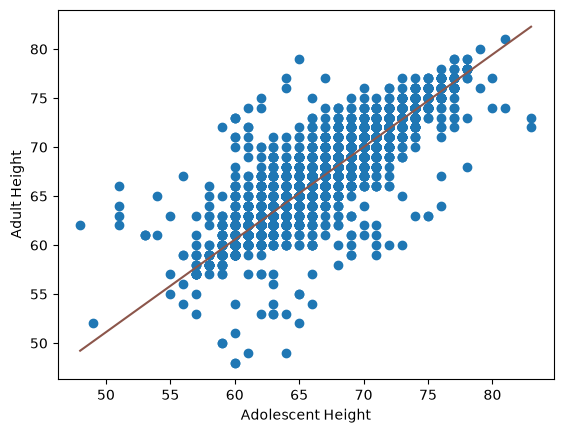

In [112]:
fig, ax = plt.subplots()

# Scatter
ax.scatter(HiWeDF["height81"], HiWeDF["height85"])
ax.set_xlabel("Adolescent Height")
ax.set_ylabel("Adult Height")


# OLS
ols = smf.ols(
    "height85 ~ height81",          # independent= omitted variable
    data=HiWeDF
).fit()

# Smooth x-values
x = np.linspace(
    HiWeDF["height81"].min(),
    HiWeDF["height81"].max(),
    100
)

# Predicted y-values
y = (
    ols.params["Intercept"]
    + ols.params["height81"] * x
)

# Regression line
ax.plot(x, y, color="C5")

plt.show()

In [ ]:
cm = HiWeDF[["height81", "height85"]].corr()


#at[] for using names of rows and columns to get a single value
#iat[] for using just numbers, here we only need any of the principle diagonal's values so we use iat

print("Correlation is", f"{cm.iat[0, 1]:.4f}")


Correlation is 0.9343


#### ii)

In [ ]:
vif= 1/(1-ols.rsquared)#1           # #1 means that in aux equation, X1 is dependent    

print("VIF =", f"{vif:.4f}")
#Because we have only 1 auxiliary equation we only have one VIF

VIF = 7.8678


#### iii)

In [119]:
print("R² is",f"{ols.rsquared:.3f}")


R² is 0.873


The auxiliary regression produced an R² of 0.873, indicating that approximately 87.3% of the variation in adult height is explained by adolescent height. This strong linear relationship suggests that the two explanatory variables are highly correlated. The corresponding VIF is 7.9, implying that the variance of the estimated coefficient is inflated by a factor of about 7.9 (or equivalently, the standard error by about 
$\sqrt{7.9}≈2.8$). This provides evidence of substantial multicollinearity between adult and adolescent height.

### c

Not including IQ may not be problem as IQ is not related to height necessarily, though an argument can be made for optimum nutrition increasing both.

Assuming they are not correlated then we just have larger error variance causing less precise coefficient estimates 

### d

Omitting eye color is not a problem because it is not a relevant determinant of wages.

# 2

In [4]:
rdt= pyreadr.read_r(r"C:\Users\khosl\OneDrive\Documents\Py notebook\Books\Real Econometrics\RE2e_Exercise Data_CH05\RE2e_R Data sets_CH05\Ch5_Exercise2_Baseball_attendence.RData")
baseballDB= rdt["dta"]
baseballDB.head()

,team,city,nickname,league,division,season,home_attend,runs_scored,runs_allowed,wins,losses,games_behind
0,ANA,Anaheim,Angels,AL,West,1997.0,1767330.0,829.0,794.0,84.0,78.0,6.0
1,ANA,Anaheim,Angels,AL,West,1998.0,2519107.0,787.0,783.0,85.0,77.0,3.0
2,ANA,Anaheim,Angels,AL,West,1999.0,2253123.0,711.0,826.0,70.0,92.0,25.0
3,ANA,Anaheim,Angels,AL,West,2000.0,2066977.0,864.0,869.0,82.0,80.0,9.5
4,ARI,Arizona,Diamondbacks,NL,West,1998.0,3600412.0,665.0,812.0,65.0,97.0,33.0


### a

In [ ]:
baseballOLS= smf.ols(
    formula="home_attend~ wins + runs_scored + runs_allowed",
    data= baseballDB
).fit()

#Report of the results
baseballOLS.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            home_attend   R-squared:                       0.296
Model:                            OLS   Adj. R-squared:                  0.293
Method:                 Least Squares   F-statistic:                     116.8
Date:                Tue, 14 Jul 2026   Prob (F-statistic):           3.77e-63
Time:                        15:49:02   Log-Likelihood:                -12384.
No. Observations:                 838   AIC:                         2.478e+04
Df Residuals:                     834   BIC:                         2.480e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept    -2.703e+05   2.37e+05     -1.140      0.254   -7.36e+05    1.95e+05
wins          3261.2078   3364.526      0.969      0.333   -3342.725    9865.141
runs_scored   4260.2154    489.056      8.711      0.000    3300.291    5220.140
runs_allowed -1682.8855    378.041     -4.452      0.000   -2424.910    -940.861
==============================================================================
Omnibus:                       57.149   Durbin-Watson:                   0.450
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               69.073
Skew:                           0.631   Prob(JB):                     1.00e-15
Kurtosis:                       3.620   Cond. No.                     1.07e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.07e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

The statistically significant coefficients are runs scored and runs allowed

Interpretation:

Runs scored\
Holding wins and runs allowed constant, scoring one additional run during the season is associated with an increase of approximately 4,260 home attendees over the season, on average.

Runs allowed\
Holding wins and runs scored constant, allowing one additional run during the season is associated with approximately 1,683 fewer home attendees, on average.

### b

For omission of the Season variable to bias the OLS estimates, two conditions must hold. First, Season must have an effect on the dependent variable, home attendance. This is plausible because U.S. population growth and other long-run changes over time could increase attendance. Second, Season must be correlated with one or more of the included explanatory variables (wins, runs scored, or runs allowed). This could occur if team performance changed over time due to rule changes, league expansion, or other historical trends. If both conditions hold, omitting Season would lead to omitted variable bias. If Season affects attendance but is uncorrelated with the included regressors, then its omission would reduce the model's explanatory power but would not bias the estimated coefficients.

### c

In [7]:
baseballOLS2= smf.ols(
    formula="home_attend~ wins + runs_scored + runs_allowed + season",
    data= baseballDB
).fit()

#Report of the results
baseballOLS2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            home_attend   R-squared:                       0.502
Model:                            OLS   Adj. R-squared:                  0.499
Method:                 Least Squares   F-statistic:                     209.6
Date:                Tue, 14 Jul 2026   Prob (F-statistic):          2.34e-124
Time:                        16:31:27   Log-Likelihood:                -12240.
No. Observations:                 838   AIC:                         2.449e+04
Df Residuals:                     833   BIC:                         2.451e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept    -8.673e+07   4.67e+06    -18.584      0.000   -9.59e+07   -7.76e+07
wins          2.349e+04   3035.254      7.740      0.000    1.75e+04    2.95e+04
runs_scored    822.5351    451.517      1.822      0.069     -63.710    1708.780
runs_allowed  -894.1252    321.076     -2.785      0.005   -1524.339    -263.911
season        4.368e+04   2355.506     18.543      0.000    3.91e+04    4.83e+04
==============================================================================
Omnibus:                       79.348   Durbin-Watson:                   0.487
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              112.952
Skew:                           0.711   Prob(JB):                     2.97e-25
Kurtosis:                       4.100   Cond. No.                     5.60e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.6e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Now all variables are statistically significant except runs scored

In [13]:
season_runscored_aux= smf.ols(
    formula="runs_scored~season",
    data= baseballDB
).fit()

#Report of the results
season_runscored_aux.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            runs_scored   R-squared:                       0.139
Model:                            OLS   Adj. R-squared:                  0.138
Method:                 Least Squares   F-statistic:                     135.1
Date:                Tue, 14 Jul 2026   Prob (F-statistic):           4.76e-29
Time:                        16:40:15   Log-Likelihood:                -5027.2
No. Observations:                 838   AIC:                         1.006e+04
Df Residuals:                     836   BIC:                         1.007e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -7704.4495    722.722    -10.660      0.000   -9123.013   -6285.886
season         4.2313      0.364     11.622      0.000       3.517       4.946
==============================================================================
Omnibus:                       26.752   Durbin-Watson:                   1.430
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               30.342
Skew:                          -0.386   Prob(JB):                     2.58e-07
Kurtosis:                       3.521   Cond. No.                     4.25e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.25e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

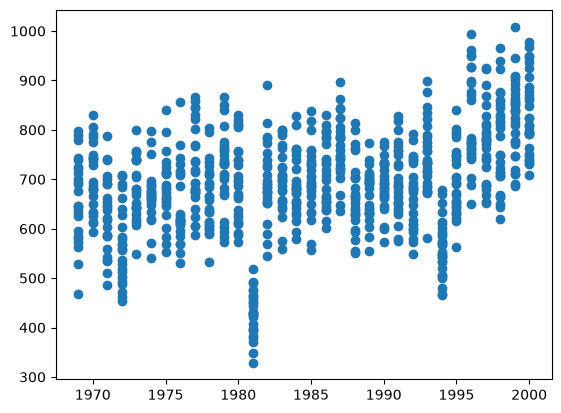

In [12]:
fig, ax = plt.subplots()

ax.scatter(baseballDB["season"], baseballDB["runs_scored"])
plt.show()

$$
R^2= 0.139\\
p < 0.0001
$$
This means that 13% of variation in runs scored is explained by season, the scatter plot as well shows that there is a slight upward trend with later years having higher runs scored, this might be due to what is called in baseball as the steroid era.

Omitting Season is likely to bias the coefficient on Runs Scored.

### e

From the regression we can say that wins are a greater driver of home attendees... actually though we can say so because runs scored is not statistically significant we should still standardize our variables because wins for a team can be 50-100 while runs can vary a lot for example 500-900, thus we need to perform standardization.

Standardization however does not change the significance, so this is not necessary but still a good practice.

In [20]:
baseballDB_std= baseballDB.copy()

baseballDB_std[["season","runs_scored", "runs_allowed","wins", "home_attend"]]= baseballDB_std[["season","runs_scored", "runs_allowed","wins","home_attend"]].apply(stats.zscore, ddof=1)
baseballDB_std[["season","runs_scored", "runs_allowed","wins", "home_attend"]].head()

,season,runs_scored,runs_allowed,wins,home_attend
0,1.287778,1.274651,0.939201,0.406394,-0.014108
1,1.395651,0.875311,0.834960,0.485300,0.980473
2,1.503524,0.152697,1.242449,-0.698289,0.628583
3,1.611396,1.607434,1.649937,0.248582,0.382317
4,1.395651,-0.284675,1.109778,-1.092819,2.411011


In [22]:
baseballOLS_std= smf.ols(
    formula= "home_attend~ runs_scored + runs_allowed + wins + season",
    data=baseballDB_std
).fit()

baseballOLS_std.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            home_attend   R-squared:                       0.502
Model:                            OLS   Adj. R-squared:                  0.499
Method:                 Least Squares   F-statistic:                     209.6
Date:                Tue, 14 Jul 2026   Prob (F-statistic):          2.34e-124
Time:                        16:55:27   Log-Likelihood:                -896.81
No. Observations:                 838   AIC:                             1804.
Df Residuals:                     833   BIC:                             1827.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept     1.188e-16      0.024   4.86e-15      1.000      -0.048       0.048
runs_scored      0.1144      0.063      1.822      0.069      -0.009       0.238
runs_allowed    -0.1248      0.045     -2.785      0.005      -0.213      -0.037
wins             0.3939      0.051      7.740      0.000       0.294       0.494
season           0.5357      0.029     18.543      0.000       0.479       0.592
==============================================================================
Omnibus:                       79.348   Durbin-Watson:                   0.487
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              112.952
Skew:                           0.711   Prob(JB):                     2.97e-25
Kurtosis:                       4.100   Cond. No.                         5.07
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In the standardized regression, the coefficient on wins (0.394) is substantially larger than that on runs scored (0.114). Furthermore, wins is statistically significant (p < 0.001), whereas runs scored is not significant at the 5% level (p = 0.069). Therefore, after controlling for runs allowed and season, winning appears to be a stronger determinant of home attendance than runs scored.

# 3

In [5]:
rdt= pyreadr.read_r(r"C:\Users\khosl\OneDrive\Documents\Py notebook\Books\Real Econometrics\RE2e_Exercise Data_CH05\RE2e_R Data sets_CH05\Ch5_Exercise3_Cell_phone_subscriptions.RData")
cellphDF= rdt["dta"]
cellphDF.head()

,year,state,state_numeric,population,numberofdeaths,urban_percent,cell_subscription,cell_ban,text_ban,total_miles_driven
0,2012.0,Alabama,1.0,4822023.0,865.0,35.0,4549.0,0.0,0.0,64959.172070
1,2012.0,Alaska,2.0,731449.0,59.0,21.0,649.0,0.0,1.0,4792.081999
2,2012.0,Arizona,3.0,6553255.0,825.0,45.0,5774.0,0.0,0.0,60129.358250
3,2012.0,Arkansas,4.0,2949131.0,552.0,19.0,2963.0,0.0,1.0,33522.136810
4,2012.0,California,5.0,38041430.0,2857.0,48.0,35616.0,1.0,1.0,326271.650600


### a

In [26]:
cellphOLS= smf.ols(
    formula="numberofdeaths~cell_subscription",
    data= cellphDF
).fit()

cellphOLS.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         numberofdeaths   R-squared:                       0.823
Model:                            OLS   Adj. R-squared:                  0.820
Method:                 Least Squares   F-statistic:                     223.6
Date:                Tue, 14 Jul 2026   Prob (F-statistic):           1.08e-19
Time:                        18:13:18   Log-Likelihood:                -352.92
No. Observations:                  50   AIC:                             709.8
Df Residuals:                      48   BIC:                             713.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept           123.9805     54.644      2.269      0.028      14.111     233.850
cell_subscription     0.0911      0.006     14.955      0.000       0.079       0.103
==============================================================================
Omnibus:                       12.676   Durbin-Watson:                   2.055
Prob(Omnibus):                  0.002   Jarque-Bera (JB):               26.955
Skew:                           0.567   Prob(JB):                     1.40e-06
Kurtosis:                       6.413   Cond. No.                     1.21e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.21e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

The results show that cell subscriptions are a very week explanatory variable as marginal effect of a cell subscription is only 0.1 increase in accidents.

But there might be problem of endogeneity
$$
Cov(X,\epsilon) \neq 0
$$

So there might be something in the error term that is related to the number of cell phones, for example factors such as population which are correlated with cell subscriptions, and in the same vain we might have urbanization play a roll. 

There might also be measurement error, a person can have 3 phones but never use them while driving but someone might have only 1 but they text on the phone constantly



### b

In [27]:
cellphOLS2= smf.ols(
    formula="numberofdeaths~cell_subscription + population",
    data= cellphDF
).fit()

cellphOLS2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         numberofdeaths   R-squared:                       0.856
Model:                            OLS   Adj. R-squared:                  0.850
Method:                 Least Squares   F-statistic:                     139.9
Date:                Tue, 14 Jul 2026   Prob (F-statistic):           1.62e-20
Time:                        18:24:45   Log-Likelihood:                -347.77
No. Observations:                  50   AIC:                             701.5
Df Residuals:                      47   BIC:                             707.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept           113.9346     49.914      2.283      0.027      13.520     214.349
cell_subscription    -0.2109      0.092     -2.285      0.027      -0.397      -0.025
population            0.0003   8.87e-05      3.278      0.002       0.000       0.000
==============================================================================
Omnibus:                       11.304   Durbin-Watson:                   1.856
Prob(Omnibus):                  0.004   Jarque-Bera (JB):               21.343
Skew:                           0.530   Prob(JB):                     2.32e-05
Kurtosis:                       6.020   Cond. No.                     1.26e+07
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.26e+07. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

After including population in the regression, the coefficient on cell phone subscriptions becomes negative and statistically significant. This indicates that, holding population constant, states with more cell phone subscriptions tend to have fewer traffic deaths on average.

This change occurs because population was an omitted variable in the bivariate model. Population is positively correlated with both the number of cell phone subscriptions and the number of traffic deaths. As a result, the bivariate coefficient on cell phone subscriptions partly reflected the effect of population. Once population is included as a control, its effect is separated from that of cell phone subscriptions, causing the estimated coefficient to change substantially.

### c

In [6]:
cellphOLS3= smf.ols(
    formula="numberofdeaths~cell_subscription + population + total_miles_driven",
    data= cellphDF
).fit()

cellphOLS3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         numberofdeaths   R-squared:                       0.922
Model:                            OLS   Adj. R-squared:                  0.917
Method:                 Least Squares   F-statistic:                     181.5
Date:                Fri, 17 Jul 2026   Prob (F-statistic):           1.69e-25
Time:                        02:57:42   Log-Likelihood:                -332.44
No. Observations:                  50   AIC:                             672.9
Df Residuals:                      46   BIC:                             680.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              4.3459     41.075      0.106      0.916     -78.335      87.026
cell_subscription      0.0025      0.077      0.032      0.975      -0.152       0.157
population         -7.422e-05   8.82e-05     -0.841      0.404      -0.000       0.000
total_miles_driven     0.0188      0.003      6.240      0.000       0.013       0.025
==============================================================================
Omnibus:                       23.142   Durbin-Watson:                   1.864
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               76.121
Skew:                           1.035   Prob(JB):                     2.96e-17
Kurtosis:                       8.680   Cond. No.                     1.39e+07
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.39e+07. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

After including total miles driven in the regression, the coefficient on cell phone subscriptions is no longer statistically significant. Total miles driven is an important explanatory variable because states where people drive more are naturally exposed to a greater risk of traffic fatalities. It is also likely to be correlated with cell phone subscriptions, since states with more drivers and greater travel may also have more cell phone users. Omitting total miles driven therefore causes the cell phone subscription coefficient to partly capture the effect of driving exposure. Once total miles driven is included as a control, this effect is separated out, and the remaining association between cell phone subscriptions and traffic deaths is no longer statistically significant.

### d

In [36]:
# Aux equation
ex_var=["cell_subscription", "population", "total_miles_driven"]

for y in ex_var:

    # all other explanatory variables
    x=[]
    for v in ex_var:
        if v != y:
            x.append(v)
            
    formula = f"{y} ~ {' + '.join(x)}"

    aux = smf.ols(
        formula=formula,
        data=cellphDF
    ).fit()

    vif = 1 / (1 - aux.rsquared)

    print(f"{y}: VIF = {vif:.2f}")

cell_subscription: VIF = 344.37
population: VIF = 492.78
total_miles_driven: VIF = 43.09


In [37]:
cellphDF[
    ["cell_subscription",
     "population",
     "total_miles_driven"]
].corr()

,cell_subscription,population,total_miles_driven
cell_subscription,1.000000,0.998186,0.979057
population,0.998186,1.000000,0.985411
total_miles_driven,0.979057,0.985411,1.000000


After including total miles driven, the coefficient on cell phone subscriptions becomes statistically insignificant. This occurs because total miles driven, population, and cell phone subscriptions are extremely highly correlated (correlations above 0.97 and VIFs well above 10). The strong multicollinearity makes it difficult for OLS to distinguish the individual effect of each variable. Consequently, the variance (and standard error) of the estimated coefficient on cell phone subscriptions increases, reducing its t-statistic and making it statistically insignificant.
$$
Var(\hat{\beta})= \frac{\hat{\sigma}^2}{{N\hspace{0.1cm} Var(X_j)(1-R^2_j)}}
$$

Her $R^2_j$ is too high

We can also calculate VIF using the a statsmodels function

In [9]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = cellphOLS3.model.exog
# This extracts the ols matrix, printing X can be a little overwhelming but we will get columns of numbers
# To know what these columns corresponds to, we get the name
print(cellphOLS3.model.exog_names)


['Intercept', 'cell_subscription', 'population', 'total_miles_driven']


In [49]:
print(X.shape)
#So X is a numpy array of 50 rows and 4 columns

(50, 4)


In [ ]:
# VIF of population (3rd on the list)

variance_inflation_factor(X, 2) #count starts from 0

np.float64(492.7789590506146)

In [ ]:
# To get all the VIF

for i in range(X.shape[1]): # We want loop run for the amount of columns
    print(
        cellphOLS3.model.exog_names[i],
        variance_inflation_factor(X, i)
    )


print("\n\n")


# To get a pretty table

vif = pd.DataFrame({
    "Variable": cellphOLS3.model.exog_names,
    "VIF": [
        variance_inflation_factor(X, i)
        for i in range(X.shape[1])
    ]
})

print(vif)

Intercept 2.2251005127288046
cell_subscription 344.3689866114946
population 492.7789590506146
total_miles_driven 43.0868043790973



             Variable         VIF
0           Intercept    2.225101
1   cell_subscription  344.368987
2          population  492.778959
3  total_miles_driven   43.086804


There is also figure 5.3 which I did not make because there is not much point in just making hard coded graphs. Instead I will make one like figure 5.3 on this regression

In [56]:
# Note that conf_int() gives us a pandaDF
display(cellphOLS3.conf_int())
print(type(cellphOLS3.conf_int()))

,0,1
Intercept,-78.334581,87.026480
cell_subscription,-0.151938,0.156868
population,-0.000252,0.000103
total_miles_driven,0.012757,0.024907


<class 'pandas.DataFrame'>


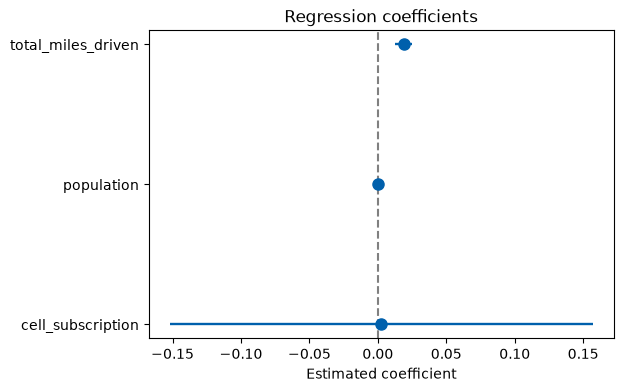

In [ ]:
# 1st we extract the beta coefficients without the intercept

coef = cellphOLS3.params[1:]      # Remove intercept

# We now extract the confidence interval for only the rows after row indexed as 0, so 1: (dont want intercept)
ci = cellphOLS3.conf_int().iloc[1:]

# We just want the number of points in y as the number of beta coefficients
y = np.arange(len(coef))

plt.figure(figsize=(6,4))

plt.errorbar(coef,y,            #coef is location of the point which will be the actual estimate that we got, we have stored that if coef, y is just y coordinates
    xerr=[
        coef - ci[0],           # matplotlib wants the distance to the left and to the right, so naturally, we will be subtracting the lower limit from our estimate to get distance to the left, and vice versa
        ci[1] - coef
    ],
    fmt='o', capsize=0, color= "#0060ac", markersize=8, elinewidth=1.7
)

plt.axvline(0, color='gray', linestyle='--')

plt.yticks(y, coef.index)

plt.xlabel("Estimated coefficient")
plt.title("Regression coefficients")

plt.show()

These both are quite useful so it would be wise to just make functions out of all these important things and store it in a .py file for future use 

In [1]:
def give_vif(ols, drop_const=True):
    """
    Calculate Variance Inflation Factors (VIF) for an OLS model.

    Parameters
    ----------
    ols : statsmodels RegressionResults
        Fitted OLS model.
    drop_const : bool, default=True
        Whether to remove the intercept from the output.

    Returns
    -------
    pandas.DataFrame
    """

    X = ols.model.exog
    names = ols.model.exog_names

    vif = pd.DataFrame({
        "Variable": names,
        "VIF": [
            variance_inflation_factor(X, i)
            for i in range(X.shape[1])
        ]
    })

    if drop_const:
        vif = vif[vif["Variable"] != "Intercept"]

    return vif.reset_index(drop=True)



# Coefficient Plot


def coefficient_plot(
    ols,
    figsize=(6, 4),
    color="#0060ac",
    title="Regression coefficients",
    show_zero=True,
):
    """
    Plot regression coefficients with confidence intervals.
    """

    coef = ols.params.iloc[1:]
    ci = ols.conf_int().iloc[1:]

    y = np.arange(len(coef))

    plt.figure(figsize=figsize)

    plt.errorbar(
        coef,
        y,
        xerr=[
            coef - ci[0],
            ci[1] - coef,
        ],
        fmt="o",
        capsize=3,
        color=color,
    )

    if show_zero:
        plt.axvline(0, color="gray", linestyle="--")

    plt.yticks(y, coef.index)

    plt.xlabel("Estimated coefficient")
    plt.title(title)

    plt.tight_layout()
    plt.show()

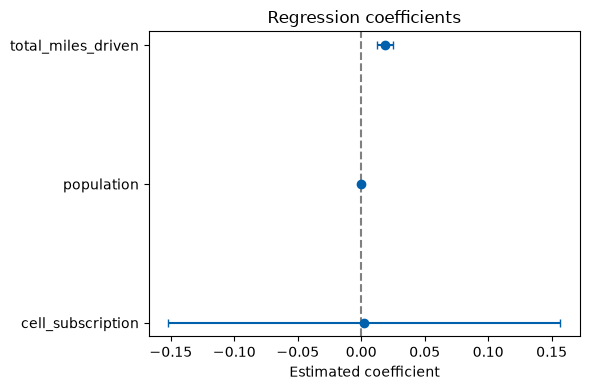

,Variable,VIF
0,cell_subscription,344.368987
1,population,492.778959
2,total_miles_driven,43.086804


In [10]:
coefficient_plot(cellphOLS3)
give_vif(cellphOLS3)

We will save these functions to AnStat.py so that we can keep expanding our lists of functions and just importing them when we need them

Question 5 and 6 are similar to the ones done 